In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('lakes_data.csv') 
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

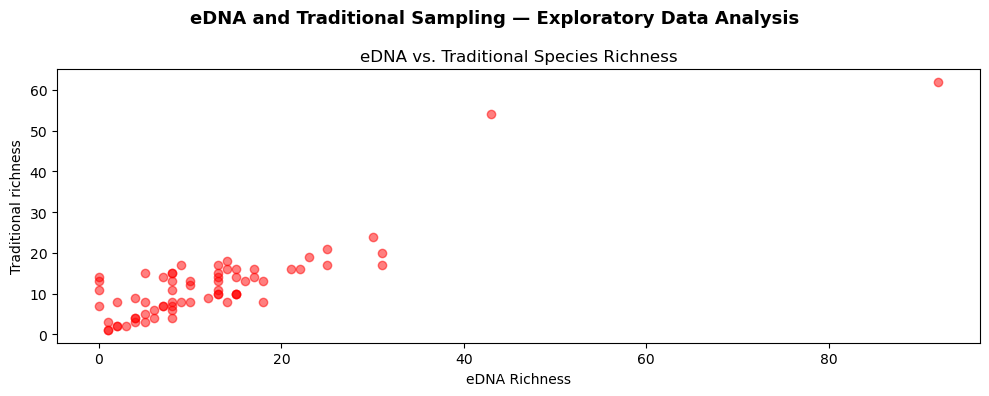

In [39]:
# Set up the figure and axes for the plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot relantionship between dna_richness and trad_richness
ax.scatter(df['dna_richness'], df['trad_richness'], alpha=0.5, color='red')
ax.set_xlabel('eDNA Richness')
ax.set_ylabel('Traditional richness')
ax.set_title('eDNA vs. Traditional Species Richness')


plt.suptitle('eDNA and Traditional Sampling — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

Yes, there appears to be a relationship between the two variables. As DNA richness increases, traditional richness also tends to increase, indicating a positive relationship. The pattern in the scatterplot is roughly linear, and the points show a moderately strong association.

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

β₁     = 0.6519
β₀     = 4.0013


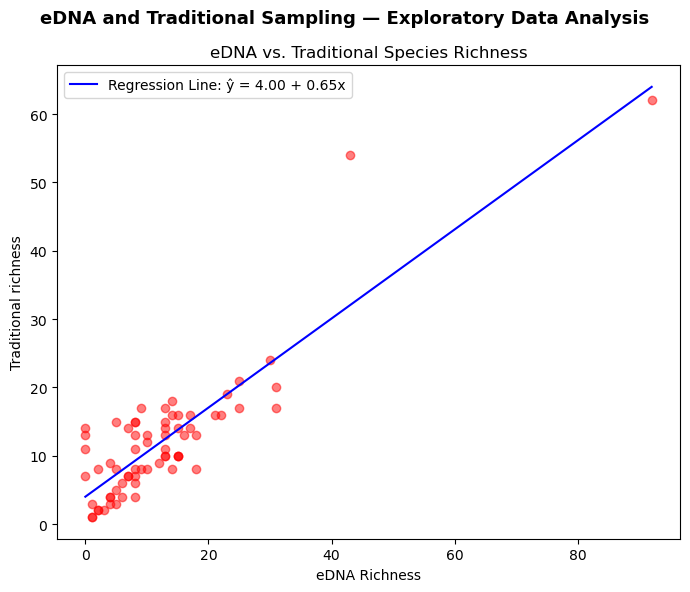

In [38]:
# Calculate the coefficients for the linear regression
x = df['dna_richness'].values
y = df['trad_richness'].values

# Means
x_bar = np.mean(x)
y_bar = np.mean(y)

# Numerator and denominator for beta_1
num = np.sum((x - x_bar) * (y - y_bar))
den = np.sum((x - x_bar)**2)

beta_1 = num / den
beta_0 = y_bar - beta_1 * x_bar

print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")

# Create the regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta_0 + beta_1 * x_line

# Plot relantionship between dna_richness and trad_richness with the regression line
# Set up the figure and axes for the plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['dna_richness'], df['trad_richness'], alpha=0.5, color='red')
ax.set_xlabel('eDNA Richness')
ax.set_ylabel('Traditional richness')
ax.set_title('eDNA vs. Traditional Species Richness')
ax.plot(x_line, y_line, color='blue', label= f'Regression Line: ŷ = {beta_0:.2f} + {beta_1:.2f}x')
ax.legend()

plt.suptitle('eDNA and Traditional Sampling — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



> **Q2:** Interpret the slope in plain language. Include units.





> **Q3:** Interpret the intercept. Is it ecologically meaningful?



Q2: For every one additional species detected by eDNA, the model predicts about 0.65 more species detected by traditional sampling
Q3: When eDNA richness is zero, the model predicts about 4 species would still be detected by traditional sampling. It might not be ecologically meaningful, because usually the intercept value is likely a result of fitting the line to the data rather than reflecting true ecological significance.

<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [6]:
# Calculate the standard errors for the coefficiets

SS_xx = np.sum((x - x_bar)**2)

y_hat = beta_0 + beta_1 * x

RSS = np.sum((y - y_hat)**2)

RSE       = np.sqrt(RSS / (len(x) - 2))
SE_beta_1 = RSE / np.sqrt(SS_xx)
SE_beta_0 = RSE * np.sqrt((1/len(x)) + (x_bar**2 / SS_xx))

print(f"RSE      = {RSE:.4f}  (species)")
print(f"SE(\u03b2\u2081)   = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080)   = {SE_beta_0:.4f}")

RSE      = 4.7441  (species)
SE(β₁)   = 0.0446
SE(β₀)   = 0.7974


In [7]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [8]:
CI_beta_1_lower = beta_1 - 2 * SE_beta_1
CI_beta_1_upper = beta_1 + 2 * SE_beta_1

CI_beta_0_lower = beta_0 - 2 * SE_beta_0
CI_beta_0_upper = beta_0 + 2 * SE_beta_0

print(f"\n95% CI for \u03b2\u2081 (slope):  ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope):  (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [9]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [10]:
R2     = 1 - (RSS / np.sum((y - y_bar)**2))

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [11]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

The R^2 of 0.7640 means that about 76% of the variation in traditional species richness across lakes can be explained by differences in eDNA richness.

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [12]:
# Fit the regression using sklearn
sk_slope     = LinearRegression().fit(x.reshape(-1,1), y).coef_[0]
sk_intercept = LinearRegression().fit(x.reshape(-1,1), y).intercept_
sk_r2        = LinearRegression().fit(x.reshape(-1,1), y).score(x.reshape(-1,1), y)

print(f"sklearn  slope     = {sk_slope:.4f},  manual slope     = {beta_1:.4f}")
print(f"sklearn  intercept = {sk_intercept:.4f},  manual intercept = {beta_0:.4f}")
print(f"sklearn  R\u00b2        = {sk_r2:.4f},  manual R\u00b2        = {R2:.4f}")

sklearn  slope     = 0.6519,  manual slope     = 0.6519
sklearn  intercept = 4.0013,  manual intercept = 4.0013
sklearn  R²        = 0.7640,  manual R²        = 0.7640


In [13]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [40]:
# Import statsmodels
import statsmodels.api as sm
# Add a constant column to X
x_sm = sm.add_constant(x)
# Fit the model
model = sm.OLS(y, x_sm).fit()
# Call summary
model.summary()
# Extract the intercept, slope, and R2
sm_intercept = model.params[0]
sm_slope     = model.params[1]
sm_r2        = model.rsquared


In [41]:
# Look at the statsmodels summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     213.7
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.25e-22
Time:                        12:55:46   Log-Likelihood:                -201.34
No. Observations:                  68   AIC:                             406.7
Df Residuals:                      66   BIC:                             411.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0013      0.797      5.018      0.0

In [16]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?


The p-value for the slope tells us whether the relationship between eDNA richness and traditional richness is statistically significant. Since the value is essentially 0 and well below the 0.05 threshold, we can reject the null hypothesis and conclude that beta_1 is different from zero, meaning there is statistically significant evidence of a positive association between the two variables. The intercept's p-value doesn't look to be the main question of interest here, but its low value indicates the regression line does not pass through the origin, meaning the intercept is significantly different from zero.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for all auto graded questions.**

In [17]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!